
# Data Wrangling & Exploratory Data Analysis  
## Hospital Readmission Prediction Using Machine Learning and DL

This notebook covers the **data wrangling** and **exploratory data analysis (EDA)** stages for the hospital readmission project using the **Diabetes 130-US Hospitals** dataset from the UCI Machine Learning Repository.

### Notebook goals
- Load and inspect the raw dataset
- Clean placeholder missing values and remove leakage-prone identifiers
- Create the binary readmission target used in modeling
- Explore class imbalance, missingness, feature distributions, and feature-target relationships
- Save clean outputs for downstream modeling

### Output files created
- `readmission_wrangled_base.csv` → cleaned but not one-hot encoded
- `cleaned_readmission_data.csv` → one-hot encoded modeling-ready dataset



## 1. Setup
Import required libraries and define the dataset source.


In [34]:

import os
import zipfile
import warnings
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)



## 2. Download and Load the Data

The project uses the **Diabetes 130-US Hospitals** dataset from UCI.

Dataset page:  
https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

This cell downloads the ZIP file directly from UCI, extracts it, and loads the main CSV.


In [35]:

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
zip_path = "diabetes_130_us_hospitals.zip"
extract_dir = "uci_diabetes_data"

if not os.path.exists(zip_path):
    urlretrieve(UCI_ZIP_URL, zip_path)

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

# Find the main CSV file
csv_candidates = []
for root, _, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_candidates.append(os.path.join(root, file))

csv_candidates


['uci_diabetes_data/IDS_mapping.csv', 'uci_diabetes_data/diabetic_data.csv']

In [36]:

data_path = [p for p in csv_candidates if os.path.basename(p) == "diabetic_data.csv"][0]
df_raw = pd.read_csv(data_path)
df_raw.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



## 3. Initial Inspection

Before cleaning, inspect:
- dataset shape
- column types
- sample records
- summary statistics


In [37]:

print("Raw shape:", df_raw.shape)
df_raw.info()


Raw shape: (101766, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 no

In [38]:

df_raw.describe(include="all").T.head(15)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983458,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0



## 4. Problem Framing and Target Definition

The original `readmitted` column has three values:
- `NO`
- `>30`
- `<30`

For this project, the target is converted into a **binary classification task**:

- `1` → readmitted within 30 days (`<30`)
- `0` → not readmitted within 30 days (`NO` or `>30`)


In [39]:

df = df_raw.copy()

df["readmitted"].value_counts(dropna=False)


NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

In [40]:

df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)
df["readmitted_30d"].value_counts(normalize=True)


0    0.888401
1    0.111599
Name: readmitted_30d, dtype: float64


## 5. Handle Placeholder Missing Values

In this dataset, several categorical fields use the string `?` instead of a true missing value.
These must be converted to `NaN` before any meaningful wrangling or analysis.


In [41]:

df = df.replace("?", np.nan)

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(15)


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
dtype: int64


### Missingness Interpretation

The variables with the most missing values are especially important because they may still carry clinical or administrative signal.  
In this dataset, fields such as **weight**, **medical_specialty**, and **payer_code** contain large amounts of missing data, which influences both preprocessing strategy and feature reliability.


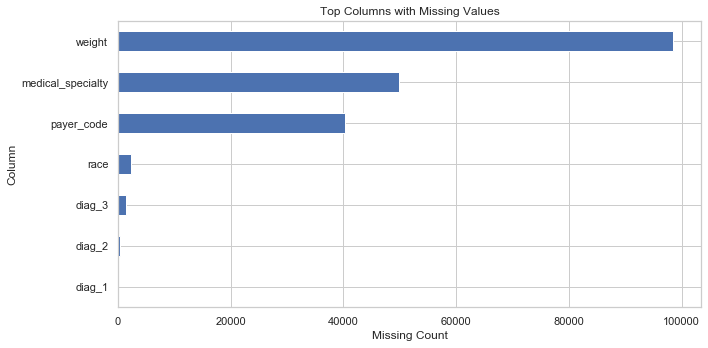

In [42]:

plt.figure(figsize=(10, 5))
top_missing = missing_counts[missing_counts > 0].head(10).sort_values()
top_missing.plot(kind="barh")
plt.title("Top Columns with Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("Column")
plt.tight_layout()
plt.show()



## 6. Remove Columns Not Appropriate for Modeling

Some columns should not be used directly in predictive modeling:
- `encounter_id` and `patient_nbr` are identifiers, not clinical predictors
- `readmitted` is the original multiclass target and would leak information once `readmitted_30d` is created


In [43]:

drop_cols = ["encounter_id", "patient_nbr", "readmitted"]
df = df.drop(columns=drop_cols)

print("Shape after dropping identifiers and original target:", df.shape)


Shape after dropping identifiers and original target: (101766, 48)



## 7. Basic Data Quality Checks

This section verifies:
- duplicate rows
- remaining data types
- whether the new target looks correct


In [44]:

print("Duplicate rows:", df.duplicated().sum())
print("\nTarget balance:")
print(df["readmitted_30d"].value_counts())
print("\nData types:")
print(df.dtypes.value_counts())


Duplicate rows: 0

Target balance:
0    90409
1    11357
Name: readmitted_30d, dtype: int64

Data types:
object    36
int64     12
dtype: int64



## 8. Save a Wrangled Base Dataset

At this stage, the dataset is:
- cleaned for placeholder missing values
- stripped of identifier leakage
- equipped with the binary target

This version is useful for:
- human-readable inspection
- EDA before one-hot encoding
- documentation of the wrangling stage


In [45]:

wrangled_base_path = "readmission_wrangled_base.csv"
df.to_csv(wrangled_base_path, index=False)
print(f"Saved wrangled base dataset to: {wrangled_base_path}")


Saved wrangled base dataset to: readmission_wrangled_base.csv



# 9. Exploratory Data Analysis (EDA)

The goal of EDA is not just to visualize the data, but to understand:
- how imbalanced the response is
- how features are distributed
- whether there are meaningful differences between readmitted and non-readmitted patients
- whether some features are better suited to linear or nonlinear models



## 9.1 Class Imbalance

This is the first and most important diagnostic because it directly affects:
- metric choice
- threshold interpretation
- minority-class detection difficulty


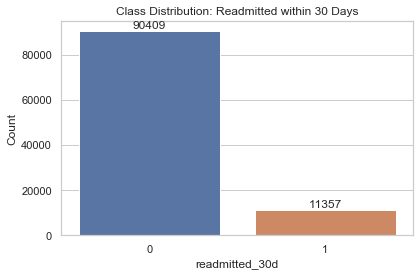

Positive class rate: 0.1116 (11.16%)


In [46]:

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="readmitted_30d", data=df)
plt.title("Class Distribution: Readmitted within 30 Days")
plt.xlabel("readmitted_30d")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

positive_rate = df["readmitted_30d"].mean()
print(f"Positive class rate: {positive_rate:.4f} ({positive_rate*100:.2f}%)")



### EDA Interpretation
The target is strongly imbalanced, with only a small share of encounters resulting in 30-day readmission.  
This means that **accuracy alone is not enough**. A model can achieve high accuracy by mostly predicting the majority class.  
That is why later modeling must emphasize **recall**, **F1 score**, **ROC-AUC**, and **precision–recall tradeoffs**.



## 9.2 Distribution of Key Numerical Features

A few numerical variables are especially useful for understanding utilization and care intensity:
- `time_in_hospital`
- `num_lab_procedures`
- `num_medications`
- `number_inpatient`
- `number_emergency`
- `number_outpatient`


In [47]:

num_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
]

df[num_features].describe().T


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0


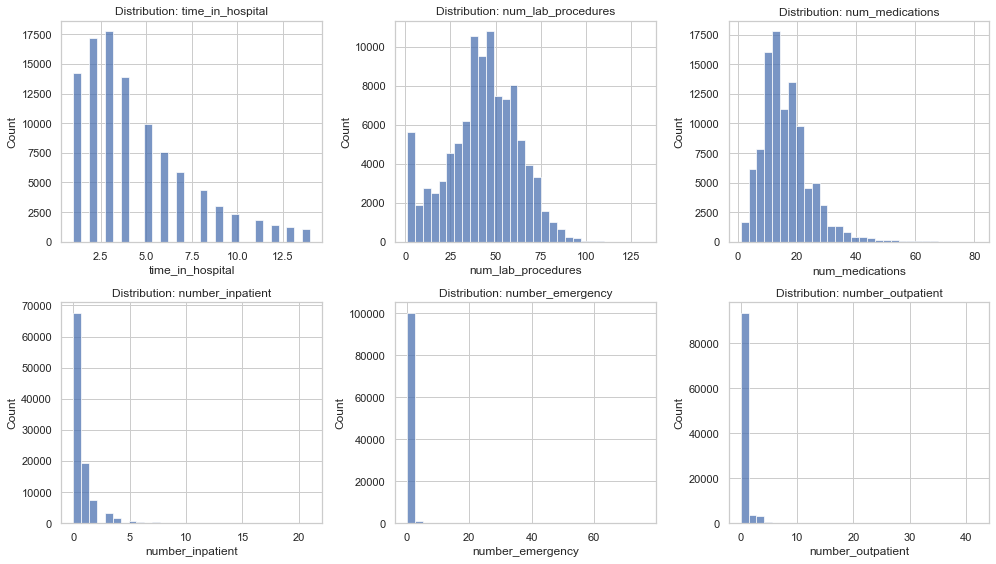

In [48]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    sns.histplot(df[col], bins=30, kde=False, ax=ax)
    ax.set_title(f"Distribution: {col}")

plt.tight_layout()
plt.show()



### Distribution Interpretation
These distributions are not close to normal. Several healthcare utilization variables are right-skewed, with many patients concentrated at lower counts and a smaller number of patients showing very high utilization.  
That matters because:
- outliers may reflect **real clinical burden**, not data error
- linear models may struggle if they assume simple relationships
- tree-based models often handle this type of structure more naturally



## 9.3 Feature vs Target: Utilization Variables

Now examine whether utilization patterns differ meaningfully between readmitted and non-readmitted patients.


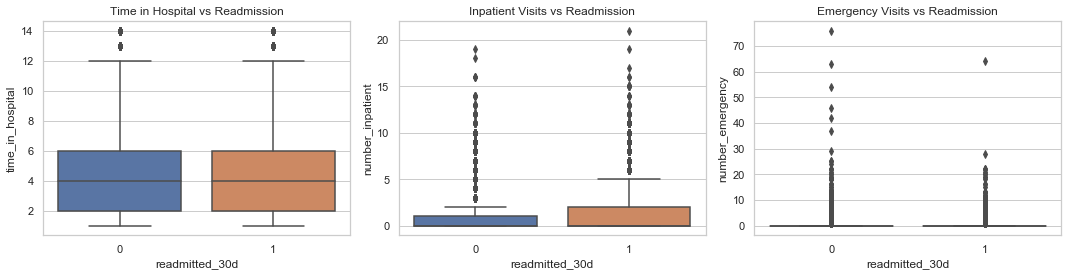

In [49]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x="readmitted_30d", y="time_in_hospital", ax=axes[0])
axes[0].set_title("Time in Hospital vs Readmission")

sns.boxplot(data=df, x="readmitted_30d", y="number_inpatient", ax=axes[1])
axes[1].set_title("Inpatient Visits vs Readmission")

sns.boxplot(data=df, x="readmitted_30d", y="number_emergency", ax=axes[2])
axes[2].set_title("Emergency Visits vs Readmission")

plt.tight_layout()
plt.show()



### Utilization Interpretation
These plots are important because hospital readmission is often driven by **care intensity and prior utilization**.  
If readmitted patients show systematically higher inpatient or emergency use, then utilization history is likely to become a strong predictive signal later in modeling.

In practical terms:
- more inpatient visits may indicate unresolved or recurring illness
- more emergency visits may reflect unstable disease management
- longer hospital stays may proxy for higher acuity or more complex care needs



## 9.4 Age and Readmission

The dataset stores age as ranges rather than exact values.  
This is still useful because it allows comparison of readmission patterns across age groups.


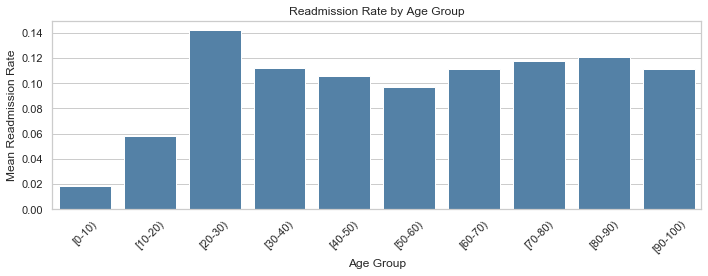

age
[0-10)      0.018634
[10-20)     0.057887
[20-30)     0.142426
[30-40)     0.112318
[40-50)     0.106040
[50-60)     0.096662
[60-70)     0.111284
[70-80)     0.117731
[80-90)     0.120835
[90-100)    0.110992
Name: readmitted_30d, dtype: float64

In [50]:

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_readmit = (
    df.groupby("age")["readmitted_30d"]
      .mean()
      .reindex(age_order)
)

plt.figure(figsize=(10, 4))
sns.barplot(x=age_readmit.index, y=age_readmit.values, color="steelblue")
plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Readmission Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

age_readmit



### Age Interpretation
Age is clinically important even if it is not the single strongest feature.  
A rising readmission rate in older groups suggests that complexity, comorbidity burden, and recovery difficulty increase with age.  
This kind of pattern often contributes useful baseline risk signal, especially when combined with utilization and diagnosis information.



## 9.5 Missingness as a Feature Context

Before modeling, it is useful to know whether the variables with high missingness are central enough to justify special handling later.


In [51]:

high_missing_cols = ["weight", "medical_specialty", "payer_code", "race", "diag_1", "diag_2", "diag_3"]
available_cols = [c for c in high_missing_cols if c in df.columns]

summary_missing = pd.DataFrame({
    "missing_count": df[available_cols].isna().sum(),
    "missing_pct": df[available_cols].isna().mean().round(4)
}).sort_values("missing_count", ascending=False)

summary_missing


,missing_count,missing_pct
weight,98569,0.9686
medical_specialty,49949,0.4908
payer_code,40256,0.3956
race,2273,0.0223
diag_3,1423,0.0140
diag_2,358,0.0035
diag_1,21,0.0002



### Missingness Interpretation
The missingness pattern is not uniform across variables. Some columns are almost fully available, while others are missing for a substantial share of records.  
This matters because later model performance can depend heavily on how these variables are encoded and imputed.  
For example, a field like `medical_specialty` may still contain useful signal even with many missing values, but its effect may be diluted if missingness dominates the distribution.



## 9.6 Prepare a Numeric Correlation View

Correlation is limited for a dataset with many categorical variables, but it can still help provide a quick view of the strongest linear relationships among numerical fields and the target.


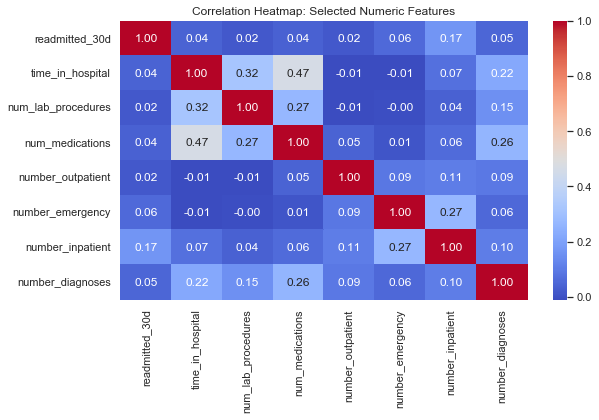

readmitted_30d        1.000000
number_inpatient      0.165147
number_emergency      0.060747
number_diagnoses      0.049524
time_in_hospital      0.044199
num_medications       0.038432
num_lab_procedures    0.020364
number_outpatient     0.018893
Name: readmitted_30d, dtype: float64

In [52]:

numeric_df = df.select_dtypes(include=[np.number])

corr_cols = [
    "readmitted_30d",
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]
corr_cols = [c for c in corr_cols if c in numeric_df.columns]

corr = numeric_df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Selected Numeric Features")
plt.tight_layout()
plt.show()

corr["readmitted_30d"].sort_values(ascending=False)



### Correlation Interpretation
The heatmap gives a compressed view of how the main numeric variables move together.  
In many healthcare datasets, the strongest useful patterns are not purely linear, so weak correlations do **not** mean a feature lacks predictive value.  
Instead, the heatmap helps answer two questions:

1. Are there obvious linear signals tied to readmission?
2. Are some features so collinear that they may provide redundant information?

If only modest correlations appear, that often supports trying nonlinear models such as Random Forest, Gradient Boosting, or a neural network.



## 9.7 Outlier Review

Outliers in healthcare data are often meaningful rather than erroneous.  
Still, reviewing them is useful because extreme values may:
- dominate plots
- affect scaling
- reflect true high-acuity patients


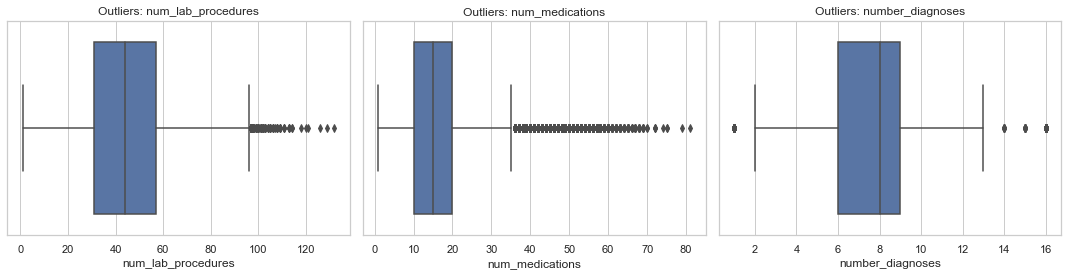

In [53]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=df["num_lab_procedures"], ax=axes[0])
axes[0].set_title("Outliers: num_lab_procedures")

sns.boxplot(x=df["num_medications"], ax=axes[1])
axes[1].set_title("Outliers: num_medications")

sns.boxplot(x=df["number_diagnoses"], ax=axes[2])
axes[2].set_title("Outliers: number_diagnoses")

plt.tight_layout()
plt.show()



### Outlier Interpretation
Extreme values are visible in several utilization and treatment variables.  
These should not automatically be removed, because high values may correspond to exactly the kind of clinically complex patients who are at highest risk of readmission.  
In this project, the outliers are better interpreted as **signal-rich cases** rather than noise unless domain review suggests otherwise.



# 10. Create Modeling-Ready Dataset

For modeling, categorical variables need to be encoded and the final matrix saved for reuse.
This keeps the modeling notebook modular and reproducible.


In [54]:

df_model = df.copy()

cat_cols = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("Modeling-ready shape:", df_model.shape)
df_model.head()


Modeling-ready shape: (101766, 2428)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30d,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100),weight_[0-25),weight_[100-125),weight_[125-150),weight_[150-175),weight_[175-200),weight_[25-50),weight_[50-75),weight_[75-100),payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Anesthesiology,medical_specialty_Anesthesiology-Pediatric,medical_specialty_Cardiology,medical_specialty_Cardiology-Pediatric,medical_specialty_DCPTEAM,medical_specialty_Dentistry,medical_specialty_Dermatology,medical_specialty_Emergency/Trauma,medical_specialty_Endocrinology,...,diag_3_V70,diag_3_V72,diag_3_V85,diag_3_V86,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,metformin_No,metformin_Steady,metformin_Up,repaglinide_No,repaglinide_Steady,repaglinide_Up,nateglinide_No,nateglinide_Steady,nateglinide_Up,chlorpropamide_No,chlorpropamide_Steady,chlorpropamide_Up,glimepiride_No,glimepiride_Steady,glimepiride_Up,acetohexamide_Steady,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_No,glyburide_Steady,glyburide_Up,tolbutamide_Steady,pioglitazone_No,pioglitazone_Steady,pioglitazone_Up,rosiglitazone_No,rosiglitazone_Steady,rosiglitazone_Up,acarbose_No,acarbose_Steady,acarbose_Up,miglitol_No,miglitol_Steady,miglitol_Up,troglitazone_Steady,tolazamide_Steady,tolazamide_Up,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,6,25,1,1,41,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
1,1,1,7,3,59,0,18,0,0,0,9,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
2,1,1,7,2,11,5,13,2,0,1,6,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1
3,1,1,7,2,44,1,16,0,0,0,7,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
4,1,1,7,1,51,0,8,0,0,0,5,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1


In [55]:

modeling_path = "cleaned_readmission_data.csv"
df_model.to_csv(modeling_path, index=False)
print(f"Saved modeling-ready dataset to: {modeling_path}")


Saved modeling-ready dataset to: cleaned_readmission_data.csv



# 11. EDA Summary and Modeling Implications

## Key findings
- The target is strongly imbalanced, so later evaluation must prioritize more than accuracy.
- Placeholder missing values are concentrated in a few clinically meaningful variables.
- Utilization variables such as inpatient and emergency use appear to carry strong signal.
- Numerical feature distributions are skewed, with meaningful outliers that likely represent real clinical burden.
- Linear correlation alone does not fully explain the problem, supporting the use of nonlinear models.

## What this means for modeling
- Compare models using **ROC-AUC**, **recall**, **F1**, and possibly **precision–recall curves**
- Retain strong utilization features because they likely drive risk ranking
- Use robust preprocessing so missingness and mixed data types do not distort model behavior
- Save both a wrangled base dataset and an encoded modeling dataset for clear workflow separation
